## Components of Langchain

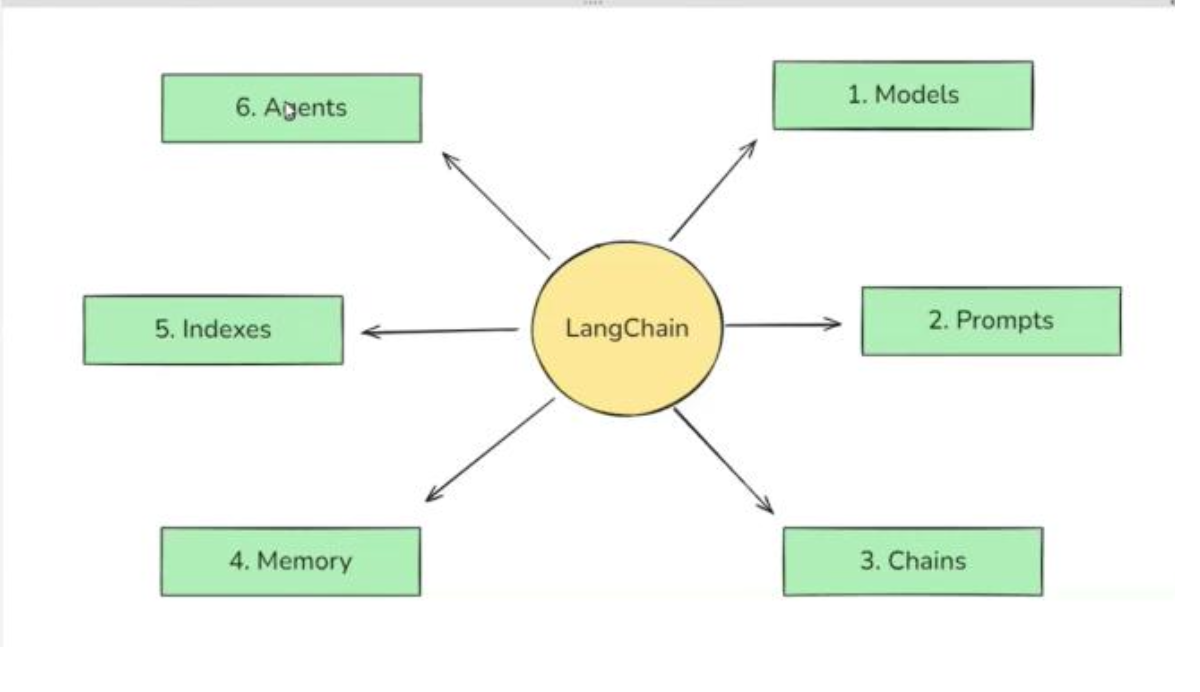

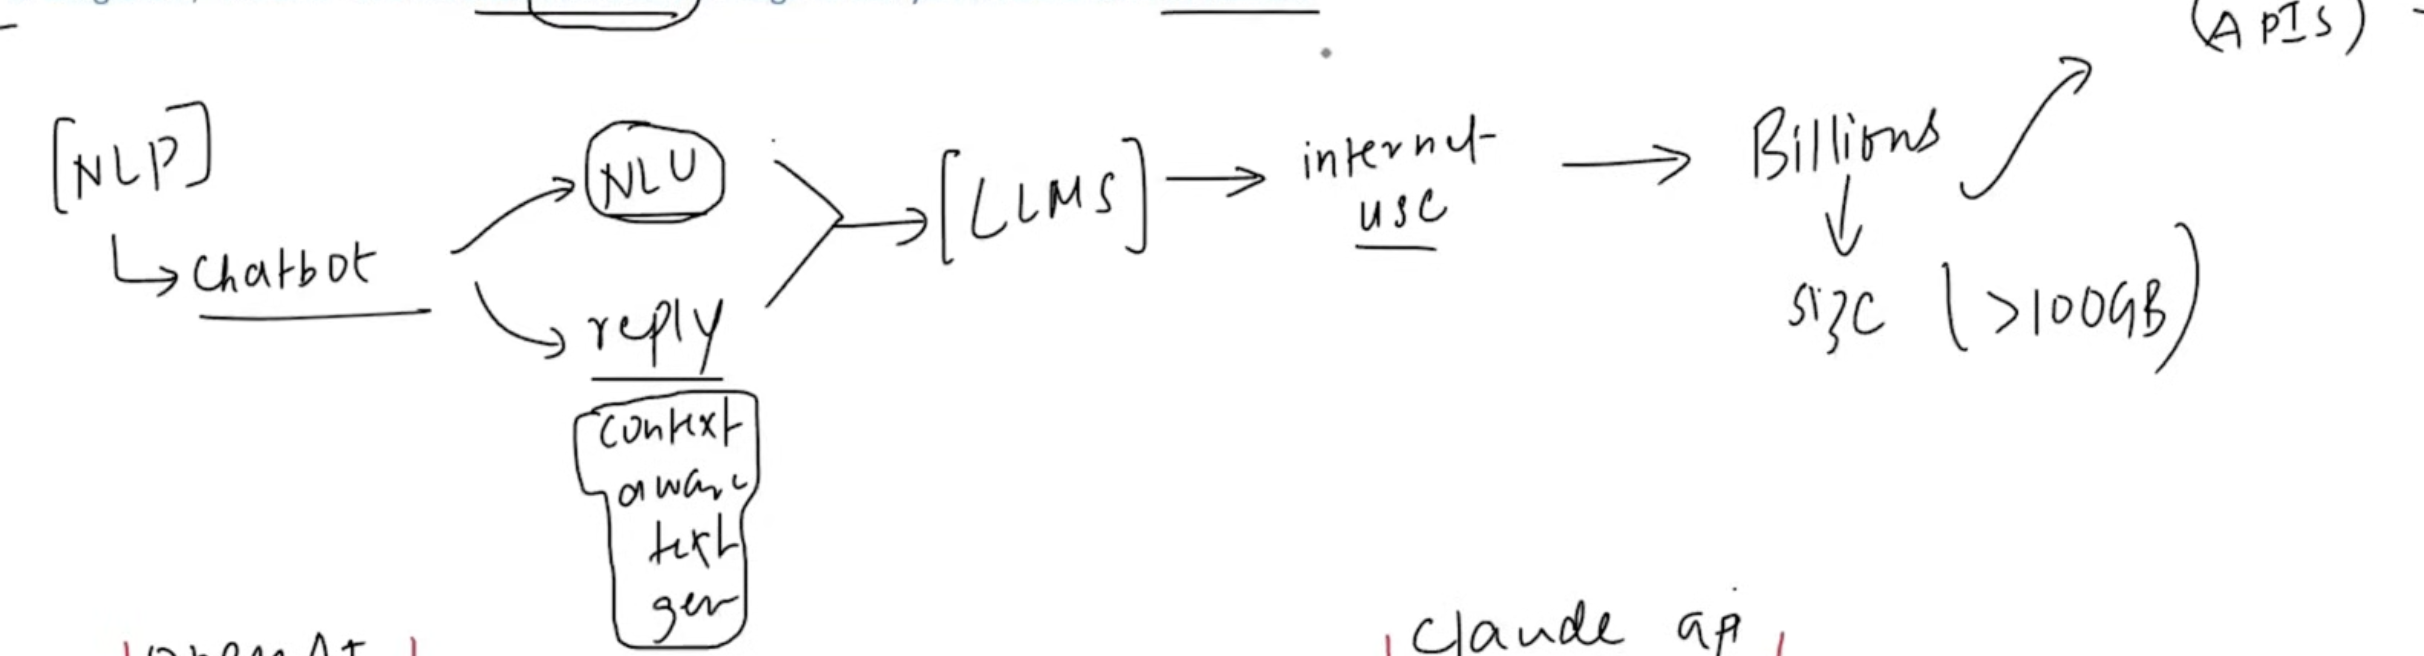

## Challenges in Building Chatbots

Building an effective chatbot involves solving two major challenges:

1. Understanding the User's Query (Natural Language Understanding)

The chatbot must first understand what the user is asking, including the intent, context, and meaning behind the query. Human language is often ambiguous and can be expressed in many different ways, making Natural Language Understanding (NLU) a difficult problem.

2. Generating the Correct Response (Context-Aware Text Generation)

Even if the chatbot successfully understands the user's query, it must still generate an accurate, relevant, and context-aware response. The response should take into account the conversation history and the specific context of the user's request.

Large Language Models (LLMs) are capable of solving both of these challenges by leveraging their extensive training on large amounts of text data.

The Challenge with LLMs

Modern LLMs contain billions of parameters and can require hundreds of gigabytes of storage and significant computational resources for inference.

Because of their enormous size and computational requirements, deploying and maintaining these models on our own servers is often impractical and expensive.

## Solution: LLM APIs

To solve this problem, companies such as OpenAI, Google, Amazon, and Anthropic host these large models on their own infrastructure and provide access to them through APIs.


When a user sends a query, the application forwards the request to the LLM API. The API communicates with the LLM running on the provider's servers, obtains the generated response, and returns it back to the application, which then sends the final response to the user.

This approach allows developers to leverage powerful LLM capabilities without worrying about infrastructure management, GPU provisioning, model deployment, or scaling challenges.

## 1.Models

## Problem: Implementation Challenges with Multiple LLM Providers

Different LLM providers expose their models through APIs, but each provider designs its API differently.

As a result, if an application developer wants to use multiple LLMs in the same application, they often need to write separate code for each provider.

For example:

Code to communicate with the GPT-4 API from OpenAI.

Code to communicate with the Claude 3 API from Anthropic.

Code to communicate with Gemini APIs from Google.

Each provider has its own:

API endpoints

Request formats

Response structures

Authentication mechanisms

Parameter names and configurations

For instance, OpenAI APIs behave differently from Anthropic APIs, and Anthropic APIs behave differently from Gemini APIs.

This creates an implementation challenge because switching from one provider to another may require significant code changes throughout the application.

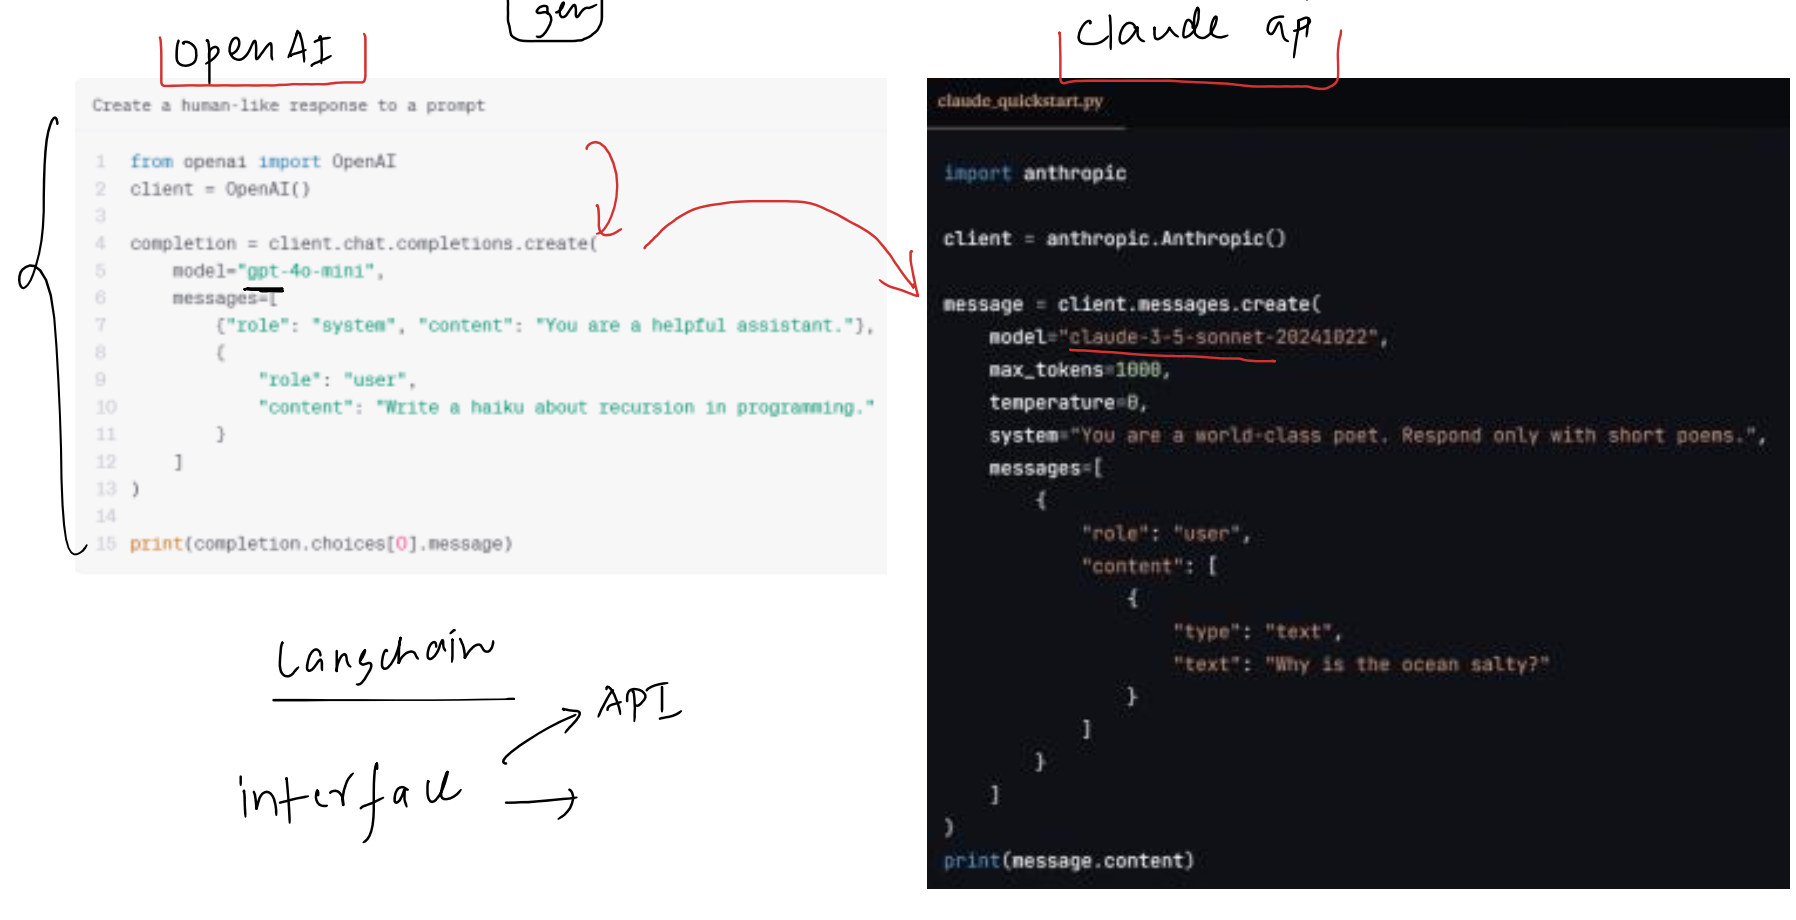

As you can see,codes for calling both the models are totally different if we don't use models component of langchain

Lang chain identifies this problem..and they made an interface through which anyone can talk
to any company’s api in a standardized fashion..
So models component of langchain solved this issue

In [ ]:
## OpenAI

from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

model=ChatOpenAI(model='gpt-4',temperature=0)
result=model.invoke("Now divide the result by 1.5")
print(result.content)

In [ ]:
## Claude

from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv

load_dotenv()

model=ChatAnthropic(model='claude-3-opus-20240229')
result=model.invoke("Now divide the result by 1.5")
print(result.content)

Now both code are very similar if we use langchain

## What does model do:

It standardizes the entire interface of communicating with the AI models


In langchain there are two types of models:

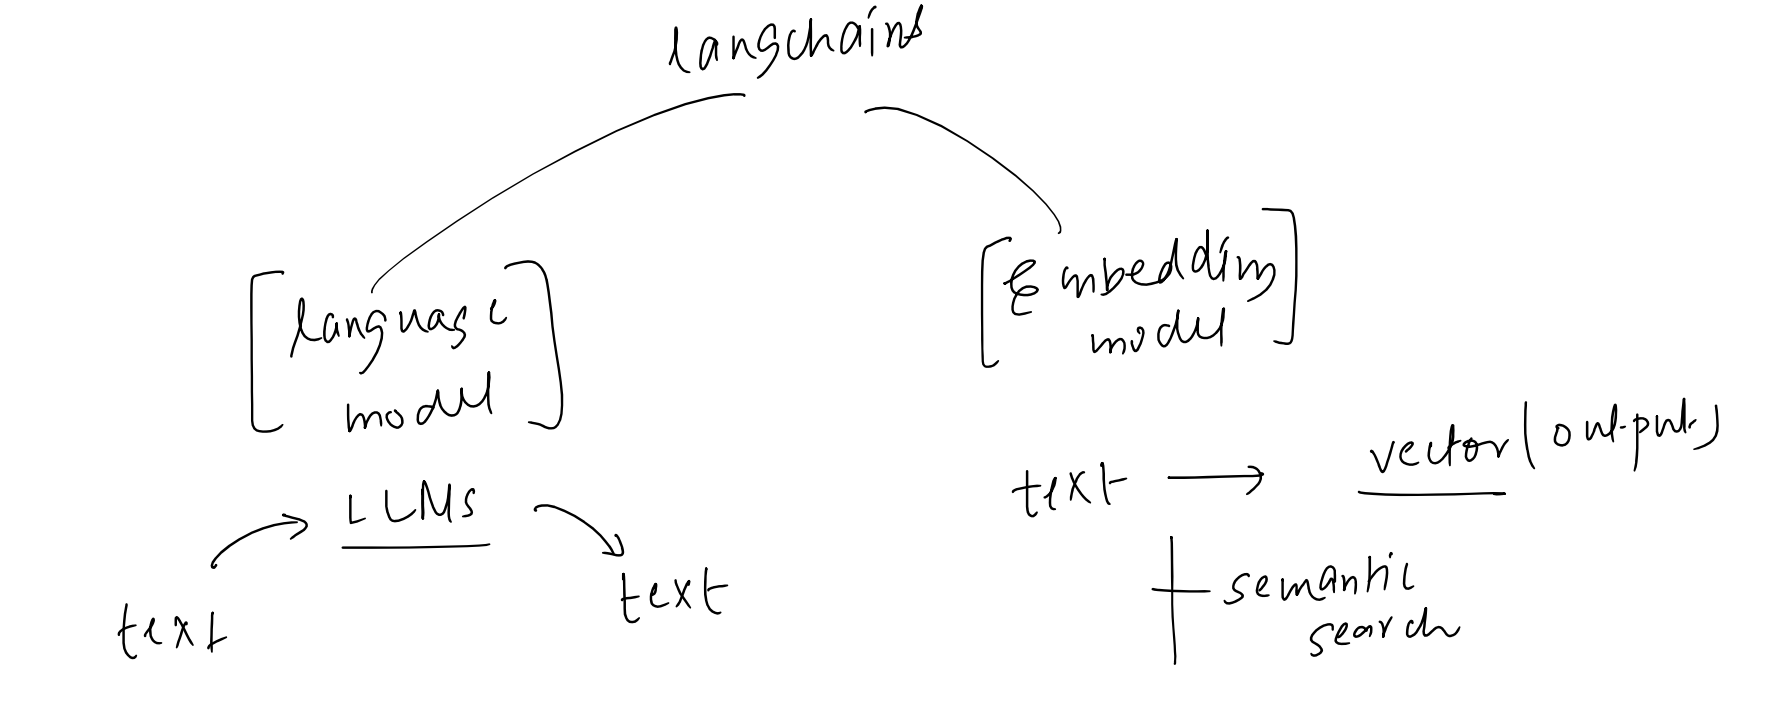


LLMs: Language Models.. Input: Text, Output: Text

Embedding Module: Input: Text, Output: Embedding/ Vector 

LangChain's Solution: The Models Component

LangChain recognized this problem and introduced a standardized interface for interacting with different LLM providers.

Using LangChain's Models component, developers can communicate with LLMs from different companies using a consistent programming interface.

The developer writes code against the LangChain abstraction rather than against a provider-specific API.

As a result:

Switching from OpenAI to Gemini requires minimal code changes.

Switching from Claude to an open-source model becomes much easier.

The application becomes more flexible and maintainable.

Vendor lock-in is significantly reduced.

This approach is known as model abstraction or model-agnostic development.

The Models component of LangChain therefore solves the problem of API incompatibility by providing a unified and standardized way to interact with different LLM providers.

## Chat Models Supported by Langchain:

Chat models are language models that use a sequence of messages as input and return messages as outputs(as opposed to using plain text).

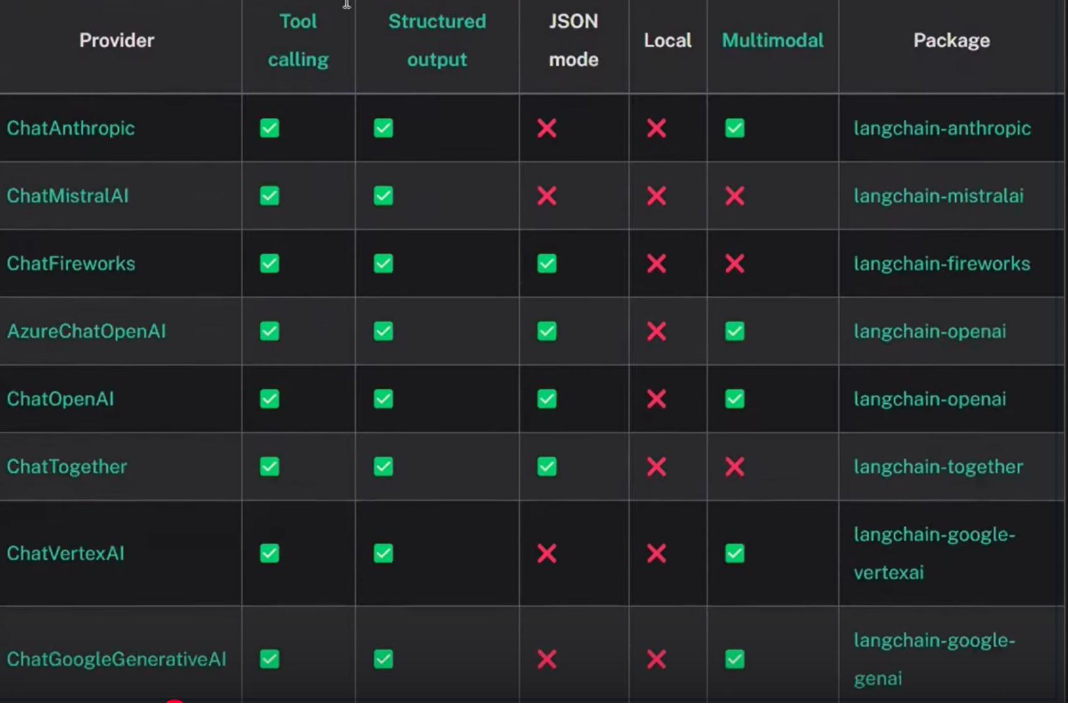

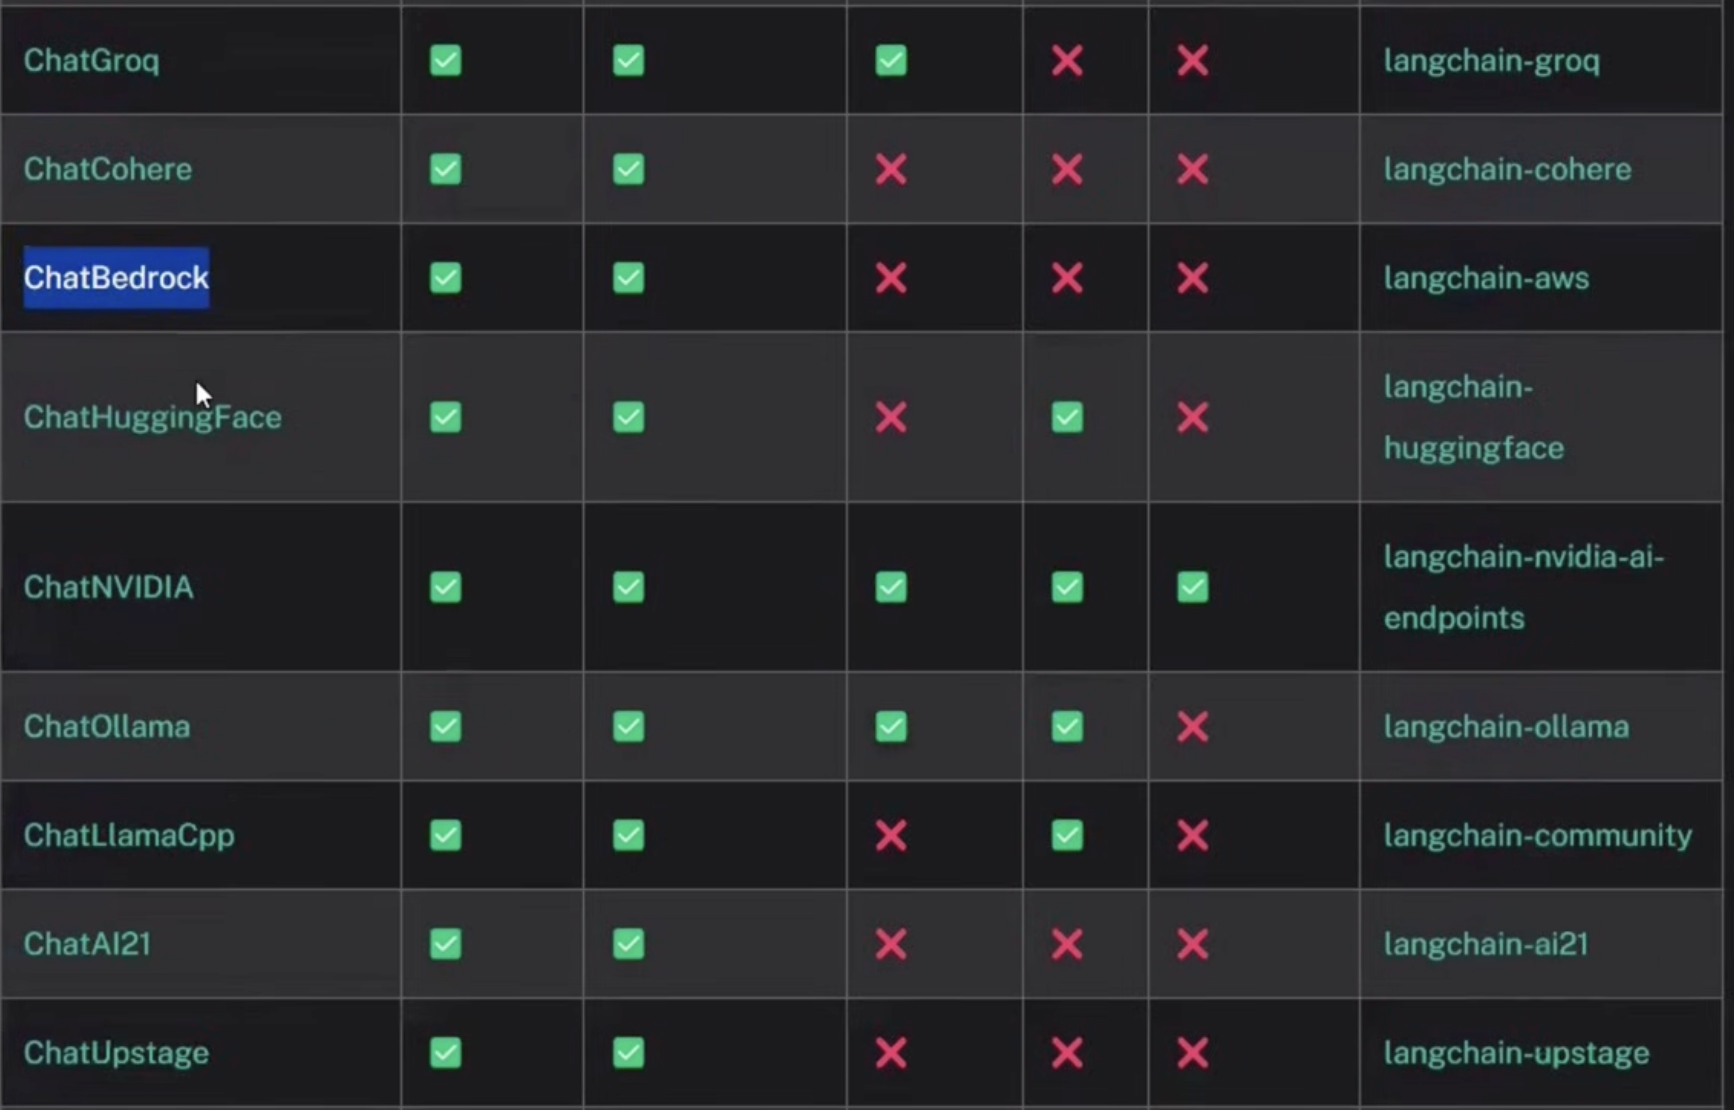

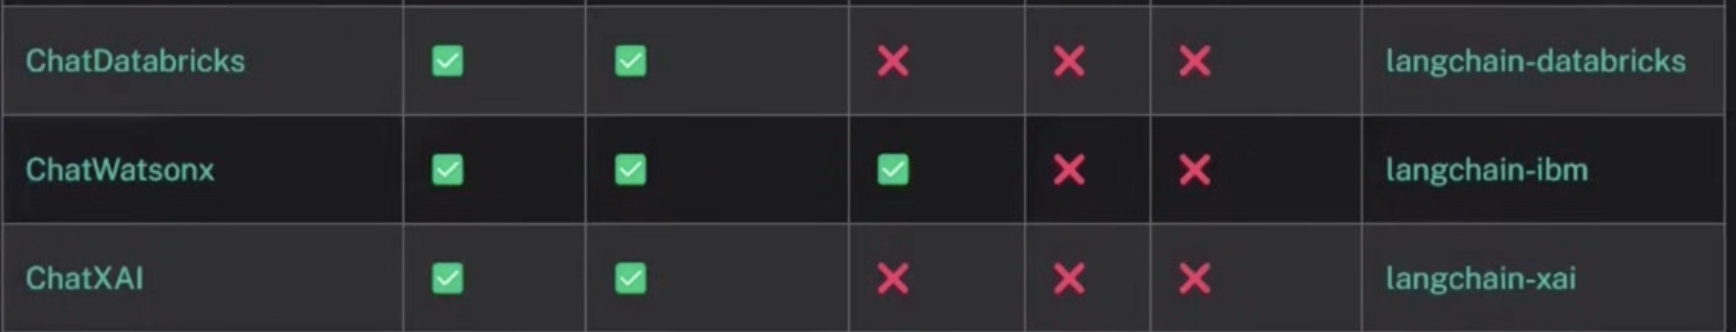

Tool Calling is available or not is used to make AI agents

can we get output as a structured format or in json mode

can we run that model locally 

can we give input as an image or audio to that model 

how to import that model through langchain

## Embedding Models Supported by Langchain:

Embedding models create a vector representation of a piece of text. 

pip install -qU langchain-openai

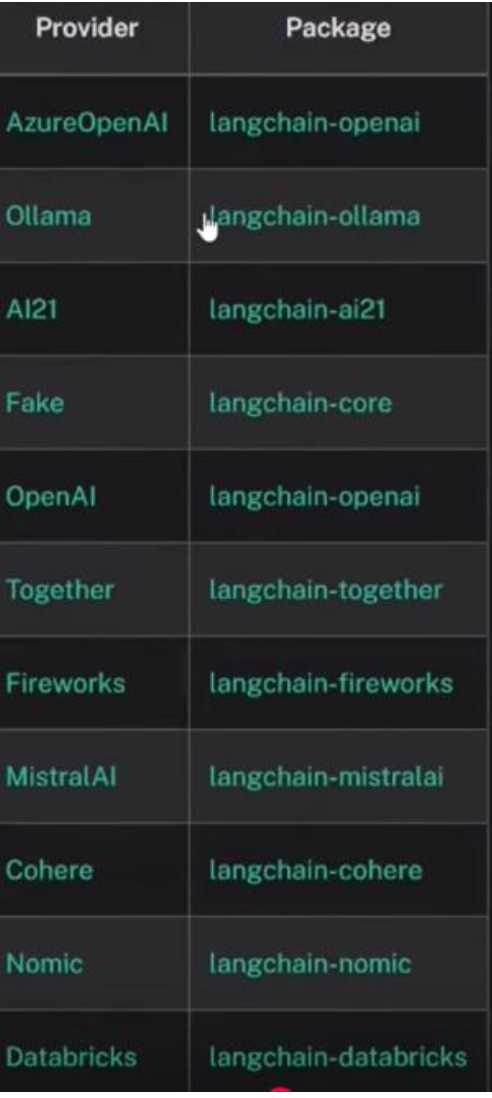

## 2. Prompts

Prompt Component in LangChain

The input that we send to an LLM is called a prompt.

The quality and accuracy of an LLM's output are highly dependent on the quality of the prompt provided as input. Even small changes in wording, structure, or context can lead to significantly different responses from the model.

In other words, the output generated by an LLM is extremely sensitive to the prompt.

LangChain recognized the importance of prompt engineering and introduced a dedicated Prompt component to manage prompts efficiently and systematically.

The Prompt component provides developers with a flexible and standardized way to create, manage, and reuse prompts across applications.

Some of the capabilities provided by LangChain's Prompt component include:

a.Creating reusable prompt templates.

b.Dynamically inserting user inputs into prompts.

c.Managing system prompts and user prompts separately.

d.Building complex prompts programmatically.

e.Combining multiple pieces of context into a single prompt.

f.Supporting prompt versioning and maintainability.

For example, instead of writing:

Explain linear regression to Priyanshu.

developers can create a template such as:

Explain {topic} to {user_name}.

and dynamically generate prompts like:

Explain linear regression to Priyanshu.

Explain neural networks to John.

Explain clustering to Alice.

This flexibility makes prompt creation more scalable, maintainable, and reusable for production-grade LLM applications.

The Prompt component in LangChain therefore plays a crucial role in improving the quality and consistency of LLM responses by providing powerful tools for prompt engineering and management.

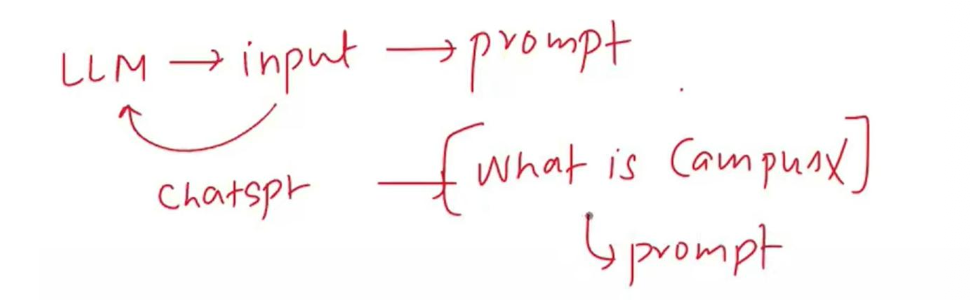

1. Dynamic and Reusable Prompts

In [ ]:
# If you don’t know in advance which topic the user will ask ai model to cover and in which tone he/she will
# ask to cover so what I can do is create a dynamic prompt

# Topic and emotion are placeholder

In [1]:
from langchain_core.prompts import PromptTemplate

prompt=PromptTemplate.from_template('Summarize {topic} in {emotion} tone')

print(prompt.format(topic='cricket',emotion='fun'))

Summarize cricket in fun tone


2. Role Based Prompts

In [9]:
# You are guiding an LLM that assume you are that much experienced in a particular field like
# doctor and now as an experienced doctor tell me about viral fever


# Note:

# PromptTemplate is for single string prompts, while your input:

# [
#  ("system","Hi you are an experienced {profession}"),
#  ("user","Tell me about {topic}")
# ]

# is a chat prompt consisting of multiple messages.

# For chat models, you should use ChatPromptTemplate.



## from_template is used for one sentence string but from_messages is used for list of str

In [10]:
from langchain_core.prompts import ChatPromptTemplate

chat_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Hi, you are an experienced {profession}."),
        ("human", "Tell me about {topic}.")
    ]
)

formatted_messages = chat_prompt.format_messages(
    profession="doctor",
    topic="viral fever"
)

print(formatted_messages)

[SystemMessage(content='Hi, you are an experienced doctor.', additional_kwargs={}, response_metadata={}), HumanMessage(content='Tell me about viral fever.', additional_kwargs={}, response_metadata={})]


3. Few Shots prompt

In [ ]:
# In few shot prompts you give some examples to the llm and then you ask question..

# Tell me based on previous examples where my new example lies in which category..

In [13]:
from langchain_core.prompts import FewShotPromptTemplate,PromptTemplate
examples=[
    {"input":"I was charged twice for my subscription this month.","output":"Billing Issue"},
    {"input":"The app crashes every time I try to log in.","output":"Technical Problem"},
    {"input":"Can you explain how to upgrade my plan?","output":"General Inquiry"},
    {"input":"I need a refund for a payment I didn't authorize","output":"Billing Issue"}
]

## step 2: create an example template

example_template="""
Ticket:{input}
Category:{output}
"""

## step 3: Build the few shot prompt template

few_shot_prompt=FewShotPromptTemplate(
    examples=examples,
    example_prompt=PromptTemplate(input_variables=["input","output"],template=example_template),
    prefix="Classify the following customer support tickets into one of the categories: 'Billing Issue', 'Technical Problem', or 'General Inquiry'.\n\n",
    suffix="\n Ticket: {user_input} \n Category:",
    input_variables=["user_input"]
)

final_prompt = few_shot_prompt.format(
    user_input="My account was debited but the payment failed."
)

print(final_prompt)

Classify the following customer support tickets into one of the categories: 'Billing Issue', 'Technical Problem', or 'General Inquiry'.




Ticket:I was charged twice for my subscription this month.
Category:Billing Issue



Ticket:The app crashes every time I try to log in.
Category:Technical Problem



Ticket:Can you explain how to upgrade my plan?
Category:General Inquiry



Ticket:I need a refund for a payment I didn't authorize
Category:Billing Issue



 Ticket: My account was debited but the payment failed. 
 Category:


## 3. Chains 

Chains are one of the core concepts in LangChain and are used to build pipelines for LLM applications.

Almost every LLM application can be represented as a sequence of tasks or a workflow. This workflow can be modeled as a pipeline, and in LangChain, these pipelines are created using chains.

## Building an LLM Application as a Pipeline

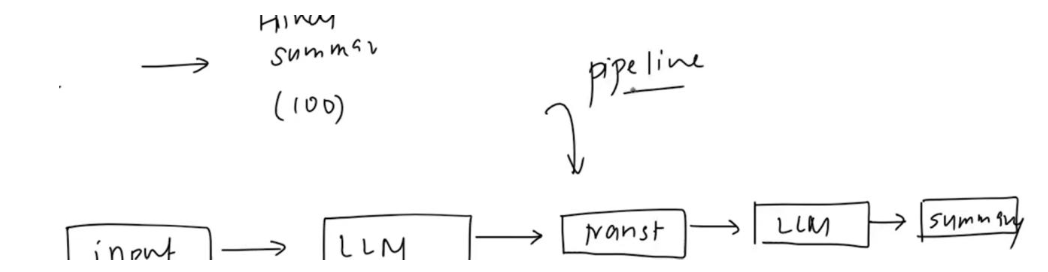

In [ ]:
# Suppose you want to build an application with the following flow:

# User Input
#     ↓
# Translate the text into English
#     ↓
# Generate a summary of the translated text
#     ↓
# Translate the summary into Hindi
#     ↓
# Return the final response to the user

# This entire flow can be represented as a pipeline.

Without Chains

If chains are not used, the developer must manually manage the flow of information between every stage.

For example:

Receive input from the user.

Send the input to the first LLM and ask it to translate the text.

Receive the translated output.

Manually extract the translated text.

Send the translated text to another LLM and ask it to generate a summary.

Receive the summary.

Manually extract the summary.

Send the summary to another LLM and ask it to translate the summary into Hindi.

Return the final output to the user.

In this approach, the developer is responsible for manually passing the output of one stage as the input to the next stage

Using Chains

Chains automate this process.

The output generated by one component automatically becomes the input to the next component in the pipeline.

As a developer, you only need to provide the initial input and execute the chain.

The chain handles all intermediate steps and data flow automatically behind the scenes.

In [ ]:
# For example:

# English Text
#     ↓
# Translation Chain
#     ↓
# Summarization Chain
#     ↓
# Hindi Translation Chain
#     ↓
# Final Output

# The developer simply provides the English text in the flow and invokes the chain.


# The chain takes care of:

# Passing outputs between stages.
# Managing intermediate results.
# Executing tasks in the correct order.
# Handling the overall workflow.


# Benefits of Chains
# Reduce boilerplate code.
# Automate data flow between components.
# Simplify pipeline management.
# Improve code readability and maintainability.
# Enable rapid development of LLM applications.

In [16]:
# Complex Pipelines

# Chains are not limited to simple sequential workflows.

# Using LangChain, developers can build:

# Sequential chains
# Parallel chains
# Conditional chains
# Multi-step reasoning pipelines
# Agentic workflows
# Retrieval-Augmented Generation (RAG) pipelines


As a result, chains make it possible to build highly complex LLM applications while keeping the code modular, maintainable, and easy to understand.

In short, chains perform most of the orchestration and workflow management behind the scenes, allowing developers to focus on the application logic rather than the plumbing between components.

## Types of Chain

1. Parallel Chain:

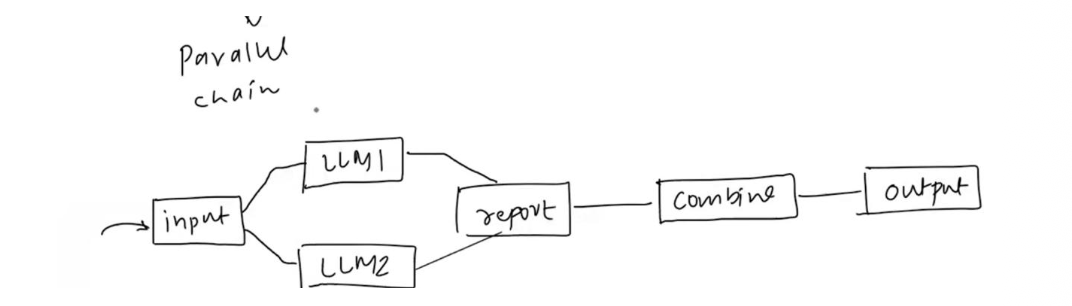

2. Conditional Chain

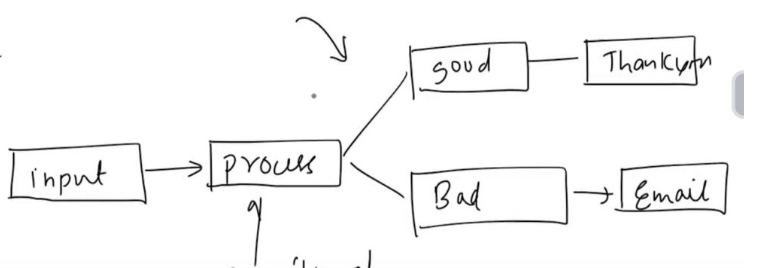

3. Sequential Chain

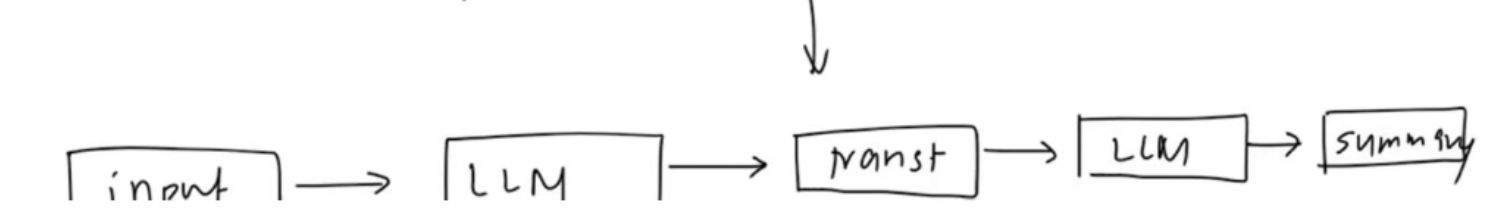

## 4. Indexes

Indexes in LangChain

In LangChain, the Indexes component is responsible for connecting Large Language Models (LLMs) with external knowledge sources.

An index is typically composed of four major components:

1. Document Loader

2. Text Splitter

3. Vector Store/Database

4. Retriever

## Why Are Indexes Needed?

Large Language Models such as ChatGPT can answer a vast number of questions because they have been trained on large amounts of publicly available data from the internet.

However, there are situations where an LLM cannot answer a question because the required information was never part of its training data.

For example, suppose you work at a company called XYZ Company, and you ask:

"What is the leave policy or notice period policy of XYZ Company?"

The LLM will most likely be unable to answer because:

The company's internal policies are private information.
The model did not see this information during training.

## Solution: Connect the LLM to an External Knowledge Source

To solve this problem, we can provide the LLM with access to external documents containing the required information.

For example:

Company policy documents

Employee rule books

Internal manuals

Technical documentation

Knowledge bases

Suppose we provide the LLM with the complete rule book of XYZ Company.

Now:

If the user asks a general question, the LLM answers using its internal knowledge
If the user asks about company policies, the LLM retrieves the relevant information from the company rule book and uses it to generate an answer.

This approach is commonly known as Retrieval-Augmented Generation (RAG).

## Step 1: Document Loader

Suppose the company rule book is stored in:

Google Drive

AWS S3

Azure Blob Storage

Local storage

The Document Loader is responsible for fetching the document from these sources and loading it into the application.

Its job is simply:

Fetch the data from the source.

## Step 2: Text Splitter

Once the document is loaded, it is divided into smaller pieces called chunks.

For example:

Rule Book:

Page 1

Page 2

Page 3

...

Page 1000

or

Chunk 1

Chunk 2

Chunk 3

...

Chunk N

This process is performed by the Text Splitter component.

Chunking is necessary because LLMs cannot process extremely large documents in a single request.

## Step 3: Vector Store

After chunking, each chunk is converted into an embedding vector using an embedding model.

For example:

Chunk 1 → Vector 1

Chunk 2 → Vector 2

Chunk 3 → Vector 3
...
Chunk 1000 → Vector 1000

These vectors capture the semantic meaning of the text.

Since these embeddings need to be reused repeatedly in the future, they are stored in a specialized database known as a:

Vector Database

Vector Store

Examples include:

FAISS
Chroma
Pinecone
Weaviate
Milvus

## Step 4: Retriever

Suppose the user asks:

"What is the leave policy of XYZ Company?"

The Retriever performs the following steps:

1. Converts the user's query into an embedding vector using the same embedding model.

2. Searches the Vector Store for document chunks with embeddings that are semantically similar to the query embedding.

3. Retrieves the most relevant chunks or pages.

4. Sends these retrieved chunks to the LLM as additional context.

This process is known as semantic search because the search is based on meaning rather than exact keyword matching.

Example Query

User asks:

"What is the leave policy of XYZ Company?"

The retriever searches the vector database and may retrieve:

Page 372

Page 461

These relevant sections are then provided to the LLM, which uses them to generate an accurate answer.

Indexes are the mechanism through which an LLM application gains access to external knowledge sources.

They enable the model to answer questions about information that was not available during training, making it possible to build domain-specific and organization-specific AI applications.

In simple terms:

Indexes are the bridge between LLMs and external knowledge sources.

## 5. Memory

LLM API calls are stateless

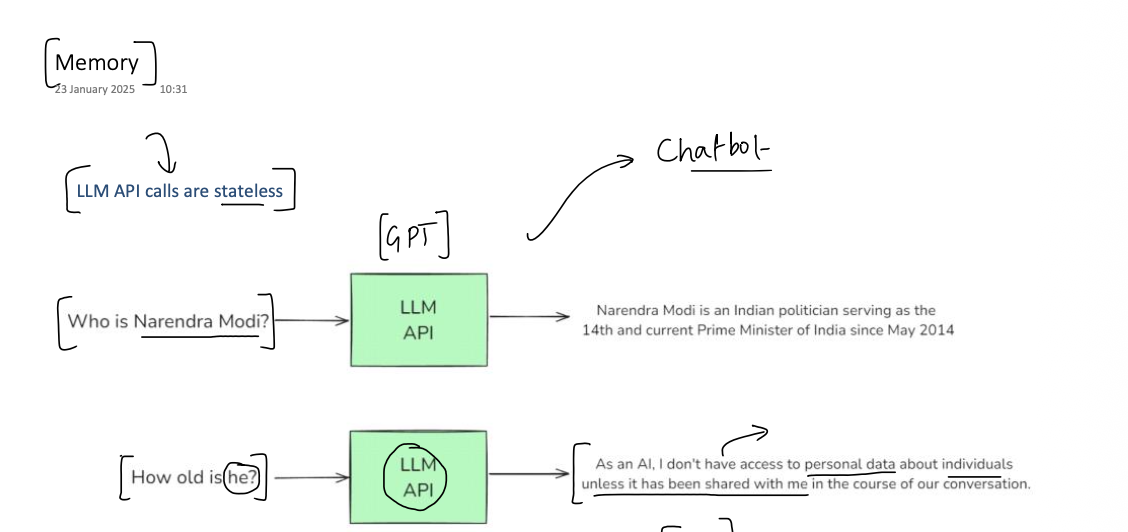

## Why do we need memory in langchain ?

Suppose you are using the OpenAI API to interact with a GPT model.

You send the following query:

Who is Narendra Modi?

The model responds with information about Narendra Modi.

Now suppose you send another query:

How old is he?

Even though a human can easily understand that "he" refers to Narendra Modi, the LLM API may fail to understand this reference.

This happens because when using LLM APIs, each API request is treated as an independent request.

In other words:

The model does not automatically remember previous conversations.

Every request is processed in isolation.

The model has no built-in memory of earlier API calls.

Therefore, from the model's perspective, the second request:

How old is he?

contains insufficient information because it does not know who "he" refers to.

## Why Does This Happen?


In [19]:
# Whenever requests are sent to LLM APIs, each request is stateless and independent.

# Request 1:
# Who is Narendra Modi?
#     ↓
# Response: Narendra Modi is the Prime Minister of India.

# Request 2:
# How old is he?
#     ↓
# Response: The model does not know who "he" refers to.

# The API does not automatically maintain conversation history between requests.

## LangChain's Solution: Memory

LangChain solves this problem using its Memory component.

Memory stores previous interactions and automatically includes the relevant conversation history in future requests sent to the LLM.

For example:

User: Who is Narendra Modi?

AI: Narendra Modi is the Prime Minister of India.



User: How old is he?

AI: Narendra Modi is 75 years old.

This works because the memory component provides the previous conversation context to the model along with the current query.

Effectively, the model receives something similar to:

Previous Conversation:
User: Who is Narendra Modi?

AI: Narendra Modi is the Prime Minister of India.

Current Question:

How old is he?

As a result, the model can correctly understand that "he" refers to Narendra Modi.

In Simple Terms

Memory enables an LLM application to:

Remember previous conversations.

Maintain context across multiple interactions.

Resolve references such as he, she, it, or they.

Provide more natural and conversational responses.

Without memory, every request behaves like a completely new conversation.

With memory, the application behaves more like a human conversation where previous context is remembered and used when generating responses.

## Types of Memory in LangChain

LangChain provides several types of memory mechanisms to maintain conversation history and context across multiple interactions.

In [20]:
# Some commonly used memory types are:

# ConversationBufferMemory
# ConversationBufferWindowMemory
# ConversationSummaryMemory
# Custom Memory

## 1. ConversationBufferMemory

ConversationBufferMemory stores the entire conversation history between the user and the chatbot.

Whenever a new API request is sent to the LLM, the complete chat history is included along with the current user query.

In [ ]:
# For example:

# User: Who is Narendra Modi?
# AI: Narendra Modi is the Prime Minister of India.

# User: Which party does he belong to?
# AI: He belongs to the Bharatiya Janata Party (BJP).

# User: How old is he?

# When the third query is sent, the model actually receives:

# Previous Conversation:
# User: Who is Narendra Modi?
# AI: Narendra Modi is the Prime Minister of India.

# User: Which party does he belong to?
# AI: He belongs to the Bharatiya Janata Party (BJP).

# Current Question:
# How old is he?

# Since the model receives the full conversation history, it can understand that "he" refers to Narendra Modi.

## Advantage:

Maintains complete conversation context.

Produces highly coherent conversations.

Disadvantage

As the conversation becomes longer, the amount of text sent to the model increases significantly.

This causes:

Higher token usage

Increased API costs

Slower response times

Context window limitations

Therefore, ConversationBufferMemory works well for short conversations but becomes inefficient for very long chats.

## 2.ConversationBufferWindowMemory

Instead of storing the entire conversation history, ConversationBufferWindowMemory stores only the last N interactions.

For example, if:

k = 5

only the last five exchanges between the user and the AI are included in future requests.

Older conversations are discarded automatically.

Advantages:

Reduces token consumption.

Lower API costs.

Faster responses.

Disadvantage:

Very old information may be forgotten.

## 3. ConversationSummaryMemory

ConversationSummaryMemory solves the problem of long conversations in a different way.

Instead of sending the entire chat history, LangChain periodically generates a summary of older conversations and sends this summary along with the recent messages.

For example:

Instead of sending:

50 pages of chat history

the model may receive:

Conversation Summary:

The user is discussing machine learning concepts including regression, classification, and neural networks.

Recent Messages:

User: Explain overfitting.

This approach significantly reduces token usage while preserving important information from earlier conversations.

Advantages:

1. Very efficient for long conversations.

2. Maintains important historical context.

3. Reduces API costs.

Disadvantage:

Some detailed information may be lost during summarization.

## 4. Custom Memory

For advanced applications, developers can create their own memory implementations.

For example, an application may store:

1-User preferences

2-Favorite topics

3-Personal settings

4-Frequently used information


Application state

Examples:

Preferred language = Hindi

Preferred model = Gemini

Subscription plan = Premium

This information can then be injected into future prompts to personalize responses.

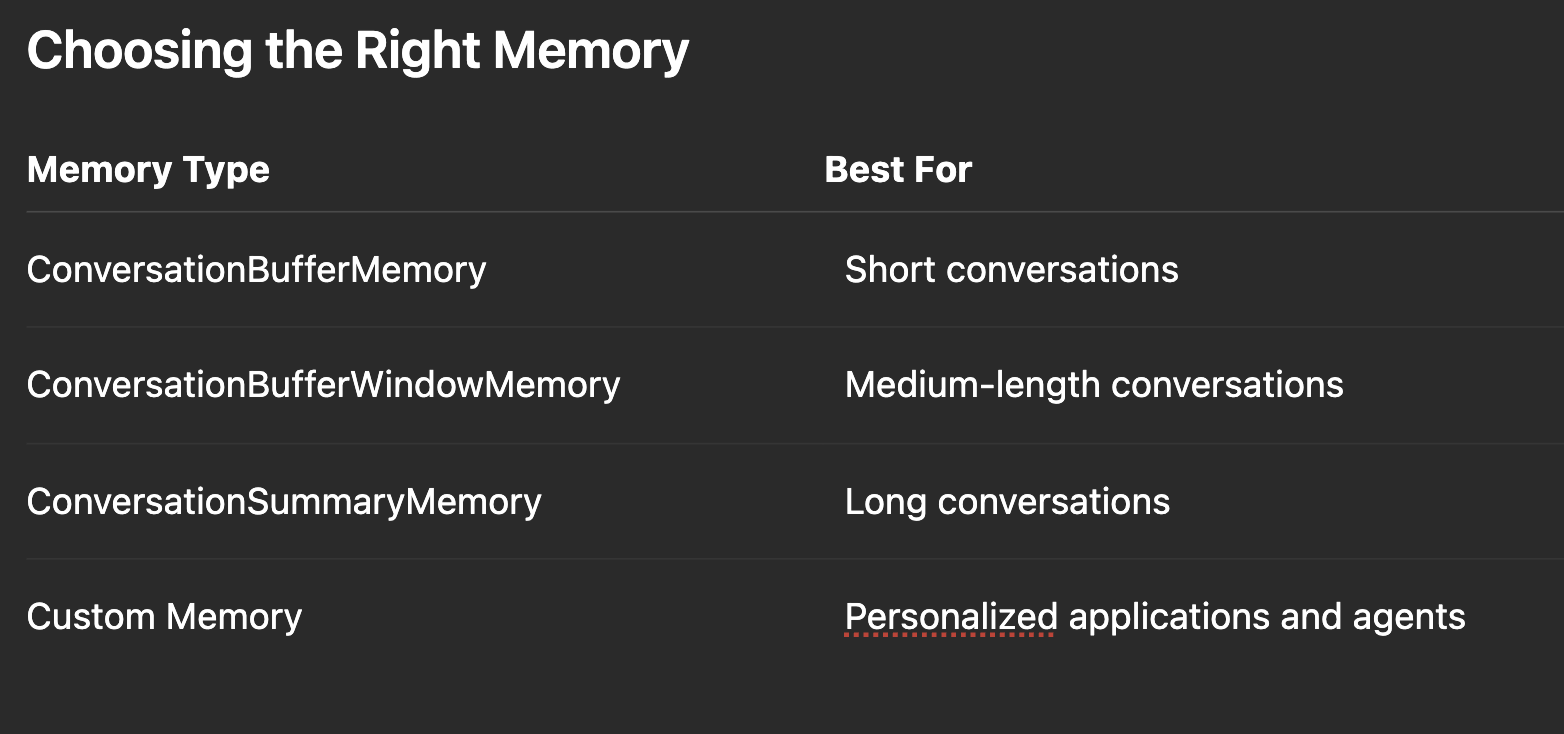

## 6. Agents

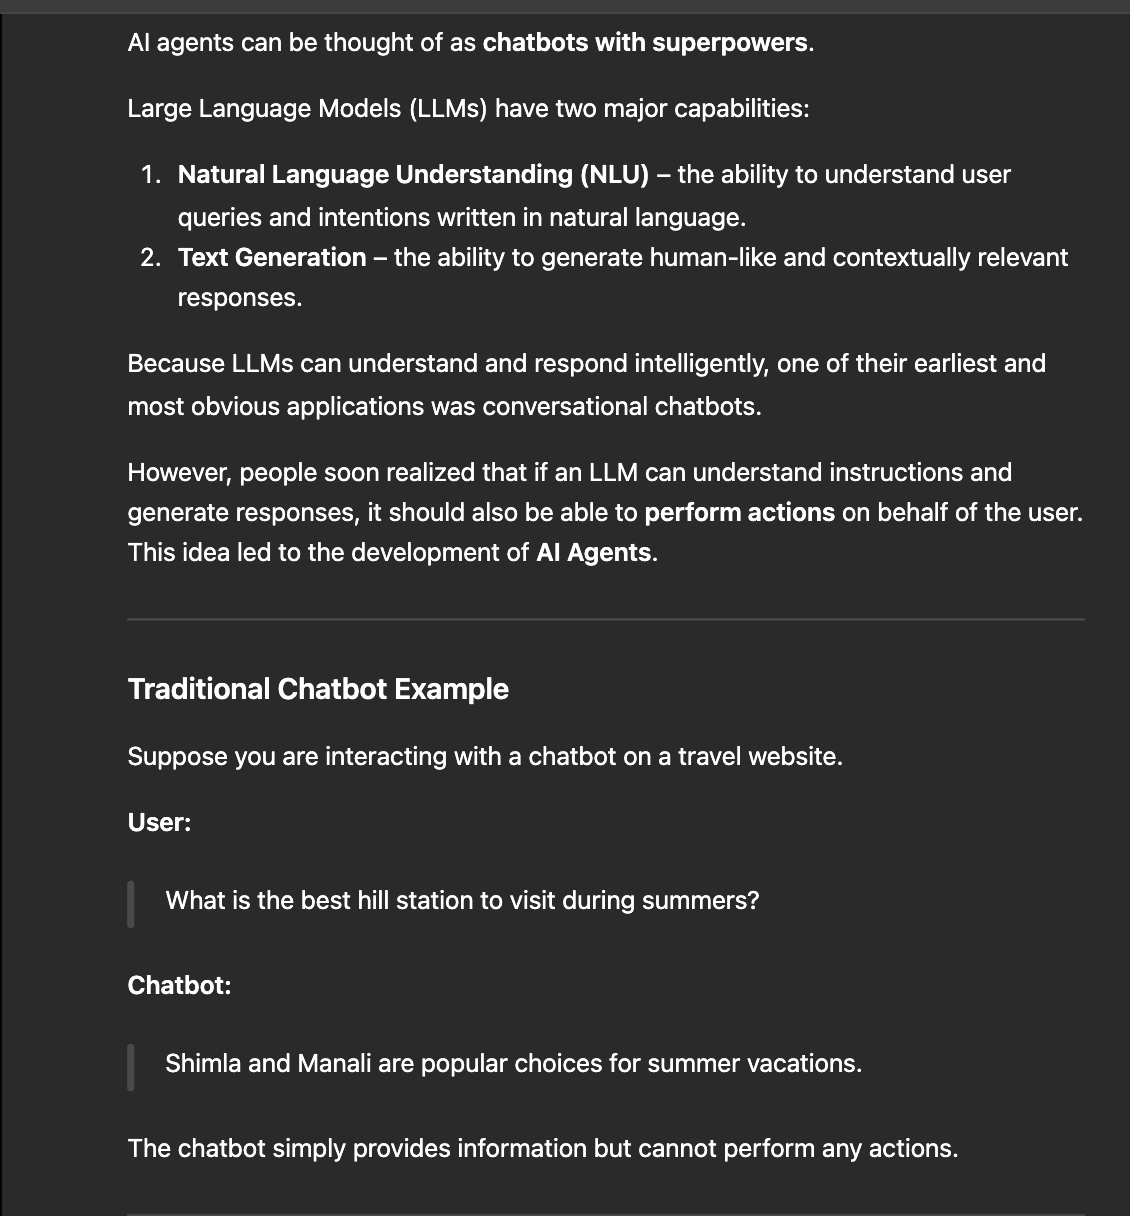

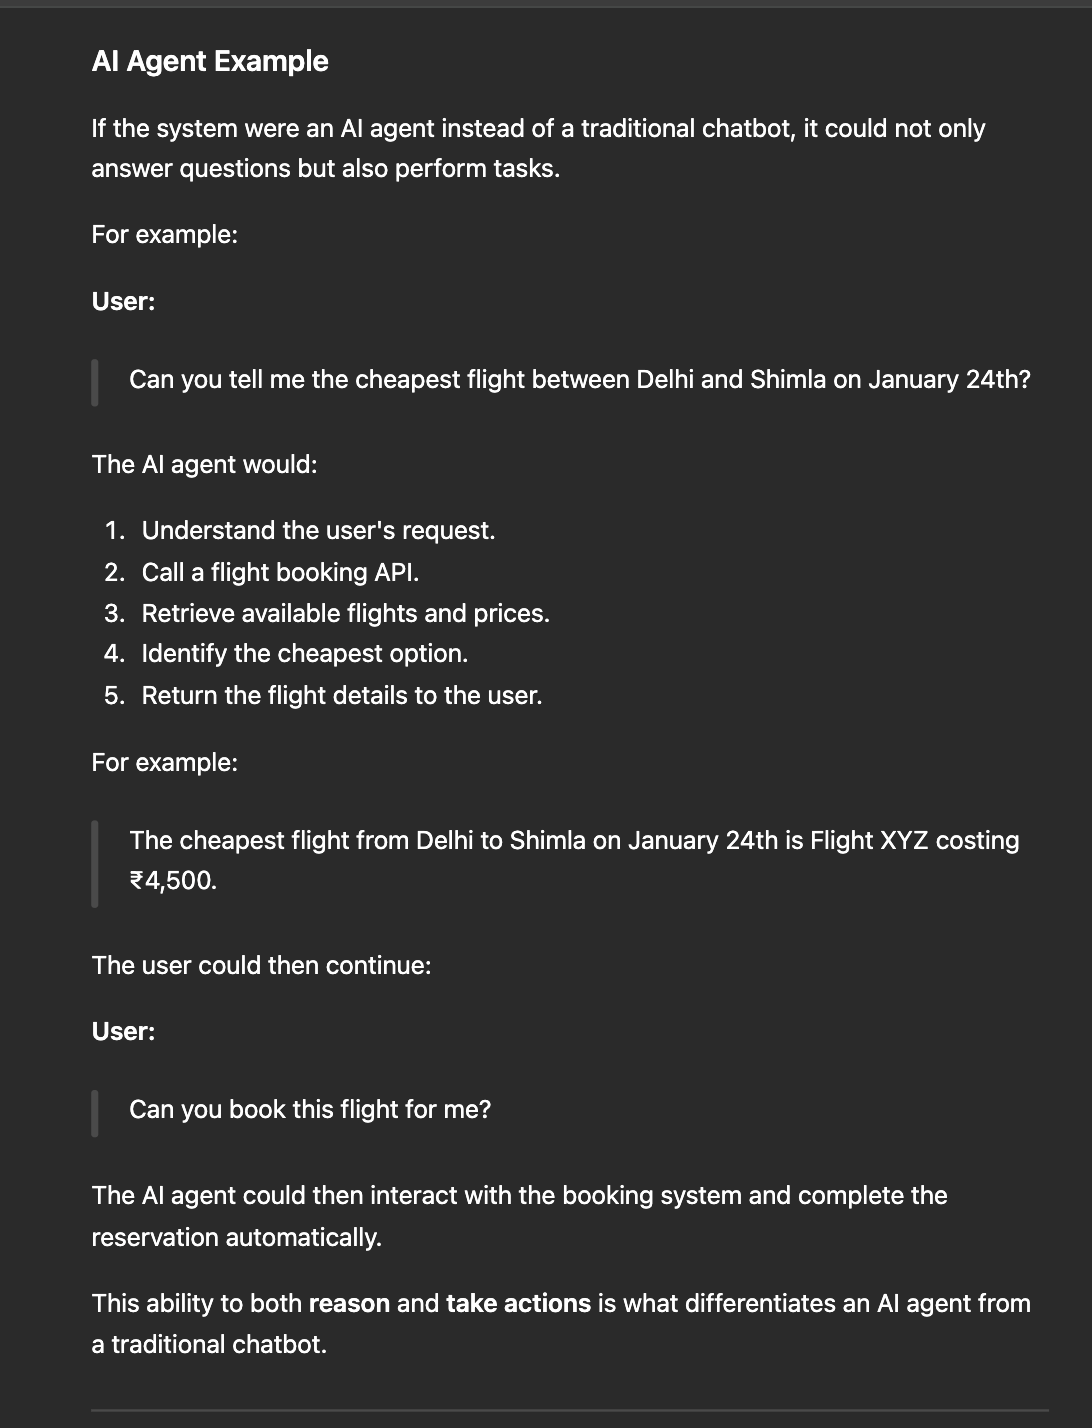

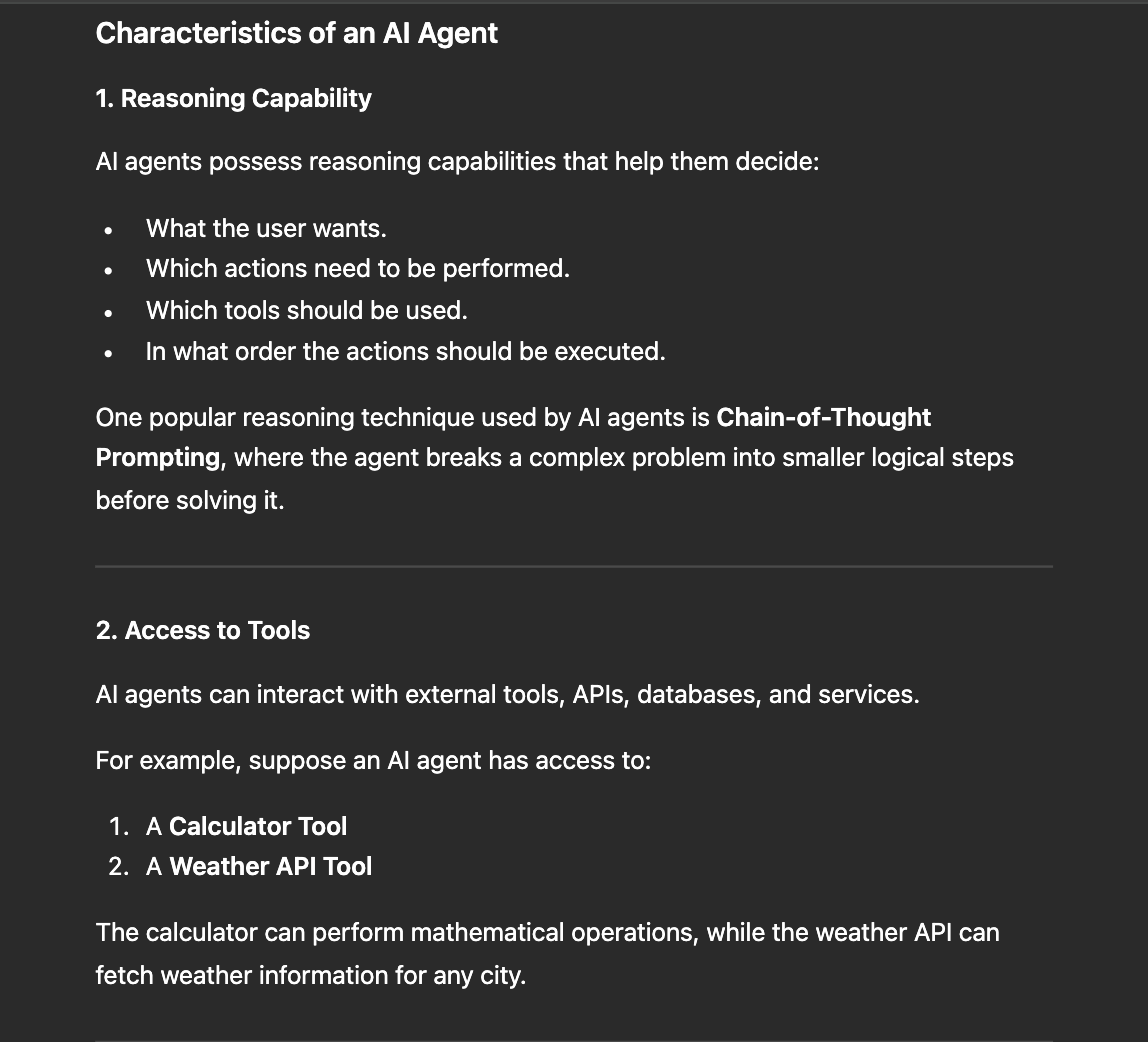
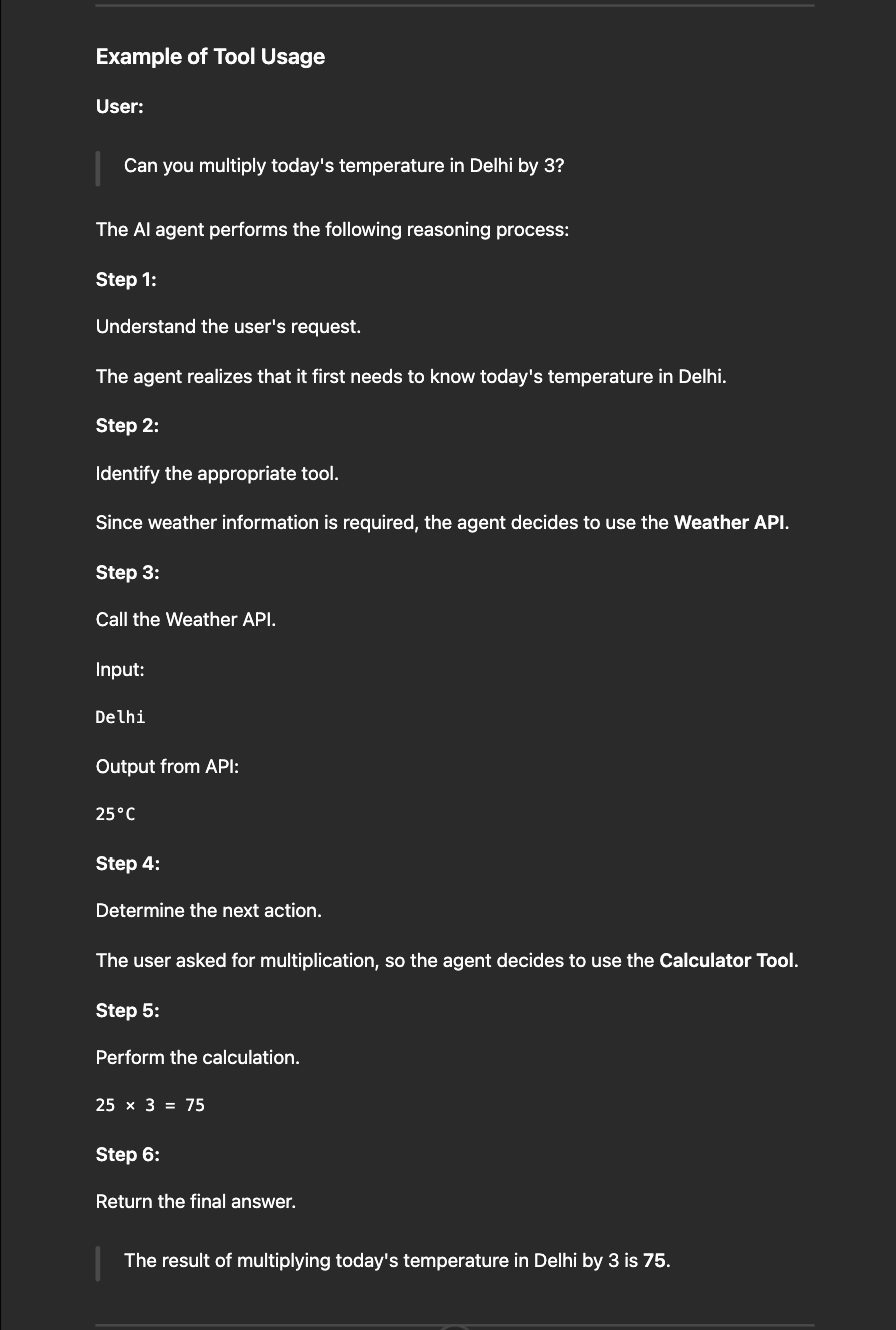
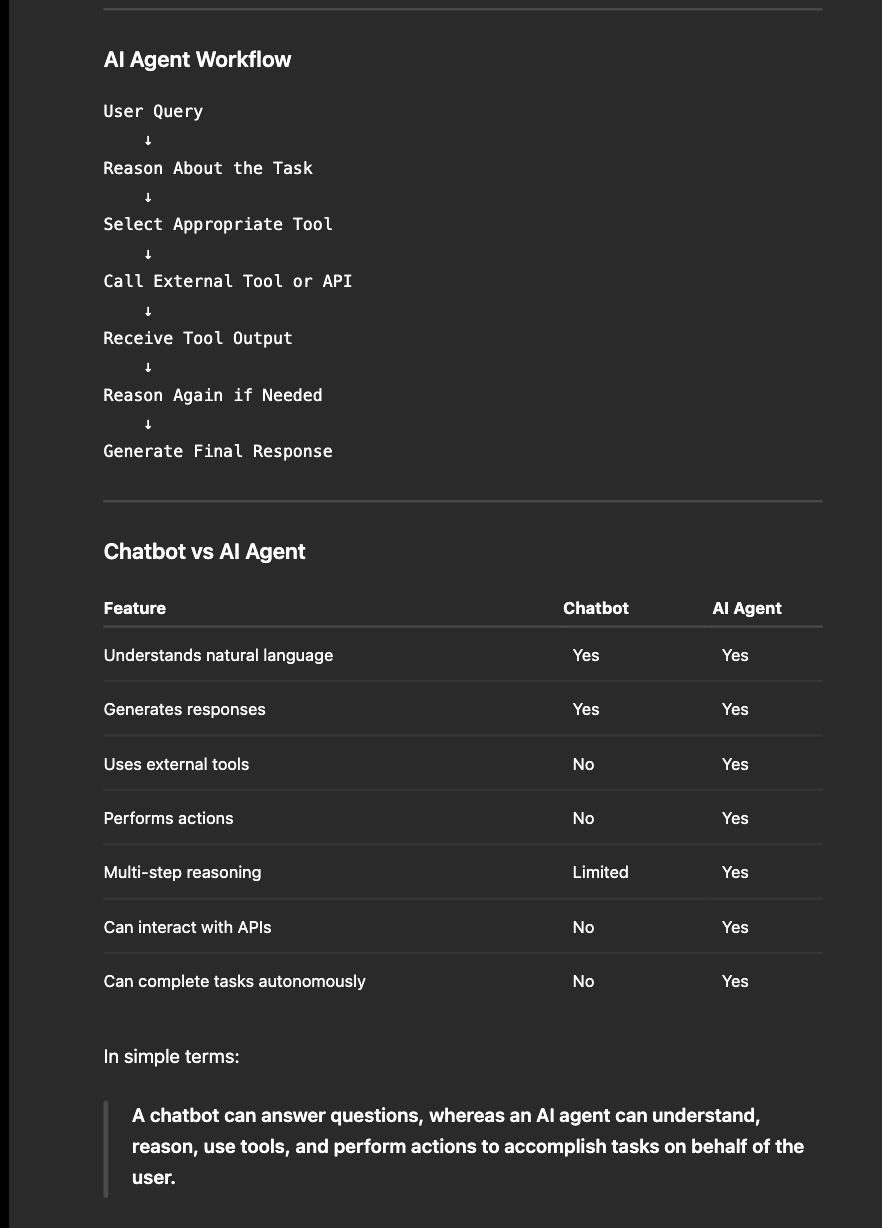